In [1]:
num_particles = 100
run_time_days = 20
time_step_minutes = 20
out_put_step_hours = 6

#initial position
lon0 = -50
lon1 = -48
lat0 = 1
lat1 = -0.5

depth_min = 1 #todo: figure near-surface depths 
depth_max = 10

offset = 200
ref_date = "1993-01-01"
#reproducibility
rdm_seed = 999

#paths
pathUVW= '/work/bk1450/b383184/Amazon/Atlantic/data/reanalysis'
# pathW= '/work/bk1450/b383184/Amazon/Atlantic/data/W'
pathTS = "/work/bk1450/b383184/Amazon/Atlantic/data/reanalysis/tracers"


In [2]:
import numpy as np

In [3]:
out_path = f'../data/tracks_{rdm_seed}/' #path to store the particle zarr

start_time = np.datetime64(ref_date) + np.timedelta64(offset, "D")
start_time

np.datetime64('1993-07-20')

## Particles from the Plume to the Atlantic

* Release particles from the plume every 5 days for 4 years (2022-2025)
* Release time 2022 to 2025
* Number of particles =  10_000
* Release depth = (0,10)
* Tracking salinity and temperature

In [4]:
from parcels import ParticleSet
from parcels import JITParticle
from parcels import AdvectionRK4_3D
from parcels import AdvectionRK4
from parcels import Variable
from datetime import timedelta
import numpy as np
from parcels import FieldSet
from glob import glob

In [5]:
np.random.seed(rdm_seed)

### Copernicus Data (C grid)

In [6]:
ufiles = sorted(glob(f"{pathUVW}/U_199*.nc"))
vfiles = sorted(glob(f"{pathUVW}/V_199*.nc"))
wfiles = sorted(glob(f"{pathUVW}/W_199*.nc"))
Tfiles = sorted(glob(f"{pathTS}/T_199*.nc"))
Sfiles = sorted(glob(f"{pathTS}/S_199*.nc"))

In [7]:
print(len(ufiles))
print(len(vfiles))
print(len(wfiles))
print(len(Tfiles))
print(len(Sfiles))

84
84
84
84
84


In [8]:
## define the fieldset
filenames = {"U": ufiles,
             "V": vfiles,
             "W": wfiles,
             "T": Tfiles,
             "S": Sfiles,
            }

variables = {
    "U": "uf",
    "V": "vf",
    "W": "w_c",
    "T": "tt_filled",
    "S": "ss_filled"
}

interp_method = {
    "U":"cgrid_velocity",
    "V":"cgrid_velocity",
    "W":"cgrid_velocity",
    "T": "linear", 
    "S": "linear"
}

dimensions = {
    "U": {"lon": "longitude_f", "lat": "latitude_f", "depth": "depth_w", "time": "time"},
    "V": {"lon": "longitude_f", "lat": "latitude_f", "depth": "depth_w", "time": "time"},
    "W": {"lon": "longitude_f", "lat": "latitude_f", "depth": "depth_w", "time": "time"},
    "T":{"lon": "longitude_f", "lat": "latitude_f", "depth": "depth_t", "time": "time"},
    "S":{"lon": "longitude_f", "lat": "latitude_f", "depth": "depth_t", "time": "time"},
}


## now the fieldset
fieldset = FieldSet.from_netcdf(
    filenames, 
    variables, 
    dimensions,
    interp_method = interp_method,
    deferred_load=True,
    allow_time_extrapolation = False,
    gridindexingtype = "nemo",
)

In [9]:
start_pos_along_line = np.random.uniform(0,1,size=num_particles)
start_lon = lon0 + start_pos_along_line * (lon1-lon0)
start_lat = lat0 + start_pos_along_line * (lat1-lat0)
start_depth = np.random.uniform(depth_min,depth_max,size=num_particles)
start_times = np.datetime64(start_time)

In [10]:
def SampleTS(particle, fieldset, time):
    # z = particle.depth
    # Optional: clamp depth to tracer range if needed
    # zmin, zmax can be added as constants if you want; otherwise omit.
    particle.temp = fieldset.T[time, particle.depth, particle.lat, particle.lon]
    particle.sal  = fieldset.S[time, particle.depth, particle.lat, particle.lon]

In [11]:
## particle age
def Age(particle, fieldset, time):
    particle.age += particle.dt / 3600

In [12]:
class SampleParticle(JITParticle):
    """
    Add variables to the standard particle class.
    Particles will sample temperature and salinity of the particle.
    """

    temp = Variable("temp", dtype=np.float32,initial=np.nan)
    sal = Variable("sal", dtype=np.float32,initial=np.nan)
    age = Variable("age", dtype=np.float32,initial=0.0)

In [13]:
# initiate pset
pset = ParticleSet(
    fieldset=fieldset,
    pclass = SampleParticle,
    lon = start_lon,
    lat = start_lat,
    depth=start_depth,
    time=start_times
) 


out_fn = f'Parcels_run_{rdm_seed}_{start_time}.zarr'

output_file = pset.ParticleFile(
    name=out_path+out_fn,
    outputdt=timedelta(hours=out_put_step_hours),
    chunks = (num_particles,int(run_time_days*24/out_put_step_hours/4))
)

In [14]:
##check the error
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

In [15]:
## Execute particles
pset.execute(
    [Age,SampleTS,AdvectionRK4_3D,CheckError],
    runtime=timedelta(days=run_time_days),
    dt=timedelta(minutes=time_step_minutes),
    output_file= output_file
)

INFO: Output files are stored in ../data/tracks_999/Parcels_run_999_1993-07-20.zarr.
100%|██████████| 1728000.0/1728000.0 [06:55<00:00, 4155.71it/s]


### Plotting

In [16]:
import xarray as xr

In [17]:
out_path = f'../data/tracks_{rdm_seed}/'
# out_fn = 'Parcels_run_692' 

ds_traj = xr.open_zarr(out_path+out_fn)
# ds_traj = ds_traj.compute()
ds_traj = ds_traj.compute()
ds_traj

<xarray.Dataset> Size: 353kB
Dimensions:     (trajectory: 100, obs: 80)
Coordinates:
  * obs         (obs) int32 320B 0 1 2 3 4 5 6 7 8 ... 72 73 74 75 76 77 78 79
  * trajectory  (trajectory) int64 800B 0 1 2 3 4 5 6 7 ... 93 94 95 96 97 98 99
Data variables:
    age         (trajectory, obs) float32 32kB 0.3333 6.333 12.33 ... nan nan
    lat         (trajectory, obs) float64 64kB -0.2051 -0.2051 ... nan nan
    lon         (trajectory, obs) float64 64kB -48.39 -48.39 -48.39 ... nan nan
    sal         (trajectory, obs) float32 32kB 0.0 0.0 0.0 0.0 ... nan nan nan
    temp        (trajectory, obs) float32 32kB 0.0 0.0 0.0 0.0 ... nan nan nan
    time        (trajectory, obs) datetime64[ns] 64kB 1993-07-20 ... NaT
    z           (trajectory, obs) float64 64kB 9.591 9.591 9.591 ... nan nan nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleAgeSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

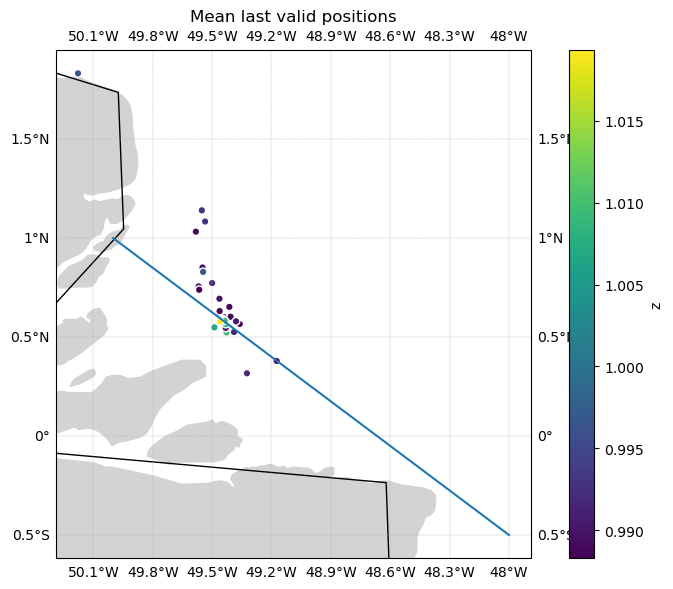

In [37]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

last_valid = ds_traj.lat.notnull().astype(int).diff('obs', label='lower') == -1
ends = ds_traj.where(last_valid).mean('obs').compute()

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines(resolution='110m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.3)

ends.plot.scatter(
    x='lon',
    y='lat',
    hue='z' if 'z' in ends else None,
    cmap='viridis',
    s=30,
    ax=ax,
    transform=ccrs.PlateCarree()
)

ax.plot([lon0, lon1], [lat0, lat1])

plt.title('Mean last valid positions')
plt.tight_layout()
plt.show()

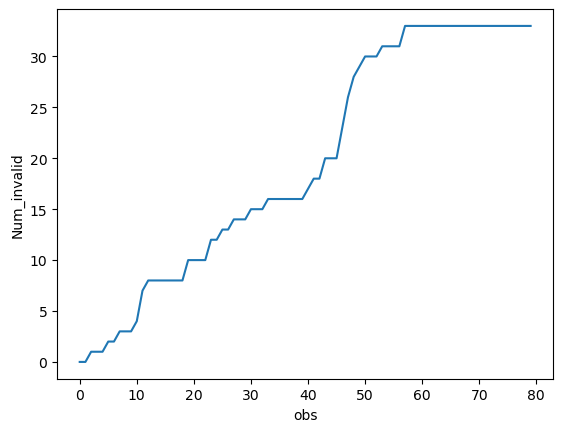

In [19]:
import matplotlib.pyplot as plt
ds_traj.lat.isnull().sum('trajectory').rename('Num_invalid').plot()
plt.show()

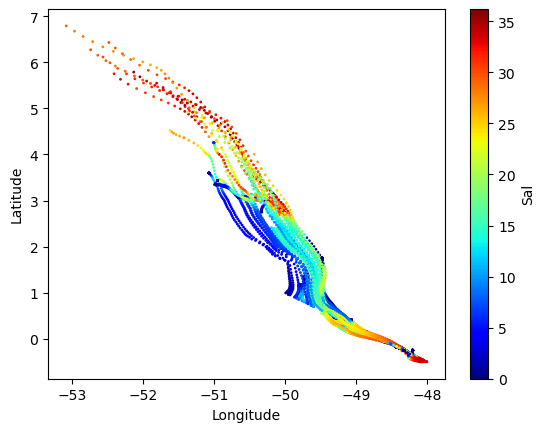

In [20]:
fig, ax = plt.subplots()
sc = ax.scatter(ds_traj.lon.values, ds_traj.lat.values,
                c=ds_traj.sal.values, s=1, cmap='jet')
cb = fig.colorbar(sc, ax=ax, label='Sal')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.show()

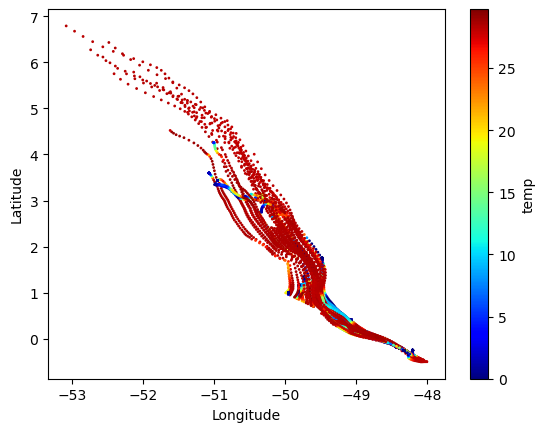

In [21]:
fig, ax = plt.subplots()
sc = ax.scatter(ds_traj.lon.values, ds_traj.lat.values,
                c=ds_traj.temp.values, s=1, cmap='jet')
cb = fig.colorbar(sc, ax=ax, label='temp')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.show()

In [22]:
ds_traj.temp.min()

<xarray.DataArray 'temp' ()> Size: 8B
array(0.)

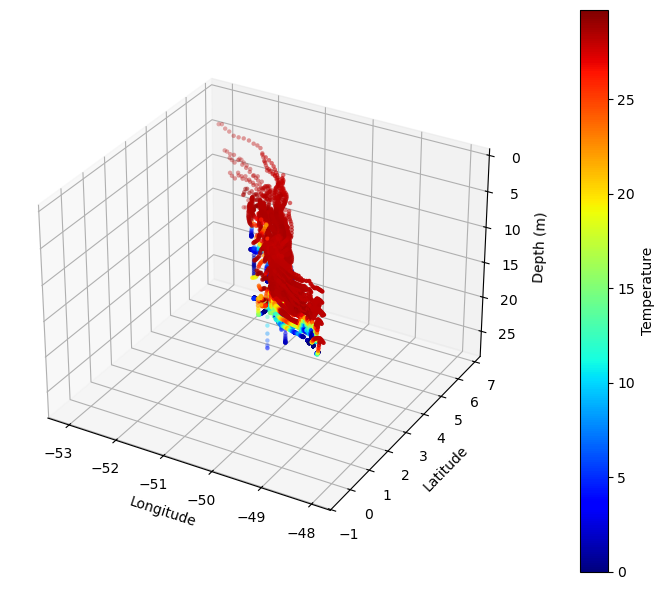

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers 3D

lon  = np.asarray(ds_traj.lon.values).ravel()
lat  = np.asarray(ds_traj.lat.values).ravel()
z    = np.asarray(ds_traj.z.values).ravel()
temp = np.asarray(ds_traj.temp.values).ravel()

# Common finite mask (avoid length mismatch)
m = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(z) & np.isfinite(temp)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(lon[m], lat[m], z[m],
                c=temp[m], s=10, cmap='jet', edgecolors='none')

cb = fig.colorbar(sc, ax=ax, pad=0.1)
cb.set_label('Temperature')

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_zlabel('Depth (m)')
ax.invert_zaxis()
plt.tight_layout(); plt.show()

In [24]:
cold = ds_traj.temp.values < 10  # °C
print("n cold points:", cold.sum())
print("example lon/lat/z:", ds_traj.lon.values[cold][:5],
      ds_traj.lat.values[cold][:5], ds_traj.z.values[cold][:5])

n cold points: 1750
example lon/lat/z: [-48.39314392 -48.39314392 -48.39314392 -48.39314392 -48.39314392] [-0.20514206 -0.20514206 -0.20514206 -0.20514206 -0.20514206] [9.59098362 9.59098362 9.59098362 9.59098362 9.59098362]


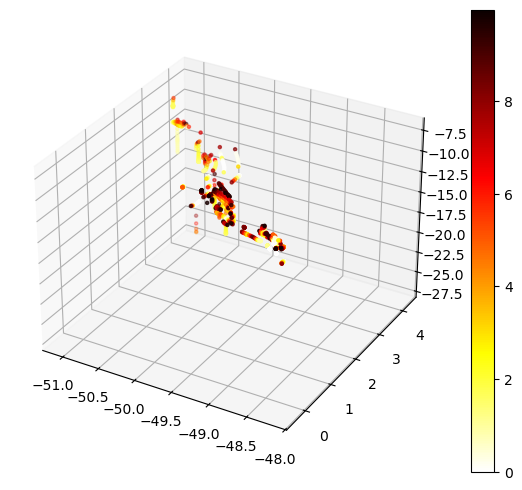

In [25]:
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(ds_traj.lon.values[cold],ds_traj.lat.values[cold],-ds_traj.z.values[cold],c=ds_traj.temp.values[cold], 
                 marker='.',cmap='hot_r')
plt.colorbar(sc)
plt.show()

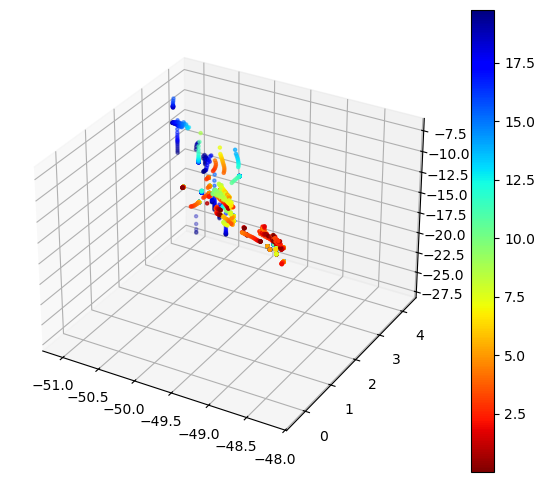

Text(0.5, 1.0, 'Age [day]')

In [26]:
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(ds_traj.lon.values[cold],ds_traj.lat.values[cold],-ds_traj.z.values[cold],c=ds_traj.age.values[cold]/24, 
                 marker='.',cmap='jet_r')
plt.colorbar(sc)
plt.show()
plt.title("Age [day]")

In [27]:
import pandas as pd

df = pd.DataFrame({"lon":ds_traj.lon.values[cold],
                   "lat":ds_traj.lat.values[cold],
                   "z":ds_traj.z.values[cold]
                  })
df.to_csv(f'Cold_points_track_{rdm_seed}.csv')

In [28]:
fieldset.V.grid

RectilinearZGrid(lon=array([-100.00, -99.92, -99.83, ..., -0.17, -0.08,  0.00], shape=(1201,), dtype=float32), lat=array([-50.00, -49.92, -49.83, ...,  49.83,  49.92,  50.00], shape=(1201,), dtype=float32), time=array([ 18921600.00,  19008000.00]), time_origin=1993-01-01T00:00:00.000000000, mesh='spherical')

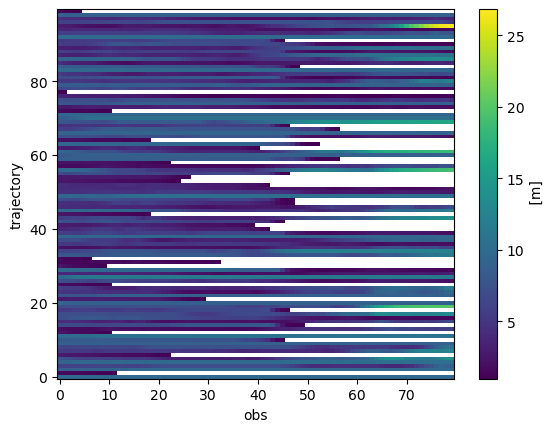

In [29]:
ds_traj.z.plot()
plt.show()